# 02 - Budget Exploration

**Objective:** Explore overall budget allocation, utilization, and revenue forecast accuracy at the portfolio level.

**Business context:** Before drilling into departments or categories, management wants headline numbers: how much budget exists, how much is spent, and how accurate is revenue forecasting overall?

*(Note: this notebook replaces the originally-planned 'sales_exploration' notebook - this dataset has no sales/order data. See `docs/assumptions_and_constraints.md`.)*

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from data_loading import load_dataset
from data_cleaning import clean_dataset
from feature_engineering import engineer_features
import kpi_calculations as kpi


In [2]:
raw = load_dataset()
cleaned, _ = clean_dataset(raw)
df = engineer_features(cleaned)
df.head()

,record_id,fiscal_quarter,department,expense_category,budget_allocated,budget_utilized,monthly_expense,revenue_forecast,actual_revenue,budget_variance,...,allocation_efficiency,budget_status,utilization_rate,budget_variance_pct,revenue_variance_pct,revenue_realization_rate,monthly_expense_to_budget,is_overspent,is_underspent,efficiency_tier
0,1,Q3,Sales,Infrastructure,55526.37,76094.72,13066.48,298866.84,110913.24,-14346.85,...,79.81,Efficient,1.370425,-0.258379,-0.075685,0.371113,0.235320,True,False,Medium
1,2,Q4,Finance,Operations,216798.15,143684.41,15238.29,102690.13,190508.00,13299.75,...,84.49,Inefficient,0.662757,0.061346,-0.209374,1.855173,0.070288,False,True,Medium
2,3,Q1,R&D,Technology,78057.00,61616.75,14073.51,268312.08,143644.82,7240.65,...,70.44,Moderate,0.789381,0.092761,-0.063995,0.535365,0.180298,False,False,Low
3,4,Q3,Sales,Operations,227312.82,54071.11,5454.20,184356.69,209880.92,-4564.39,...,96.90,Inefficient,0.237871,-0.020080,-0.092645,1.138450,0.023994,False,True,High
4,5,Q3,Marketing,Training,195954.53,146367.90,13113.98,75224.25,159960.48,-5646.62,...,95.84,Inefficient,0.746948,-0.028816,-0.167531,2.126448,0.066924,False,False,High


## Q: What is total budget allocated and utilized, and what's the utilization rate?

In [3]:
summary = kpi.kpi_summary(df)
print(f"Total Allocated: ${summary['total_budget_allocated']:,.2f}")
print(f"Total Utilized:  ${summary['total_budget_utilized']:,.2f}")
print(f"Utilization Rate: {summary['overall_utilization_rate']:.2%}")

Total Allocated: $1,019,783,032.04
Total Utilized:  $978,883,735.36
Utilization Rate: 95.99%


## Q: How is revenue forecasting performing overall?

In [4]:
print(f"Revenue Forecast: ${summary['total_revenue_forecast']:,.2f}")
print(f"Actual Revenue:   ${summary['total_actual_revenue']:,.2f}")
print(f"Realization Rate: {summary['revenue_realization_rate']:.2%}")

Revenue Forecast: $1,250,614,857.82
Actual Revenue:   $1,202,028,524.86
Realization Rate: 96.12%


## Distribution of Allocation Efficiency

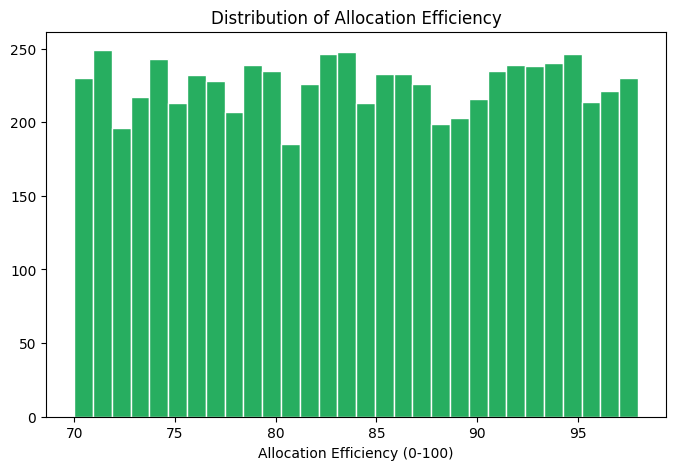

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df['allocation_efficiency'], bins=30, color='#27ae60', edgecolor='white')
ax.set_title('Distribution of Allocation Efficiency')
ax.set_xlabel('Allocation Efficiency (0-100)')
plt.show()

**Interpretation:** Efficiency scores range roughly 70-98 with a fairly uniform spread - no sharp cluster at either extreme, consistent with a synthetic, evenly-distributed field.

## Budget Status mix

In [6]:
df['budget_status'].value_counts(normalize=True).round(3)

budget_status
Efficient      0.340
Inefficient    0.334
Moderate       0.326
Name: proportion, dtype: float64

## Findings

- Overall utilization rate is 95.99% and revenue realization rate is 96.12% - both close to, but under, 100% at the aggregate level.
- Budget_Status splits almost evenly three ways (34.0% / 33.4% / 32.6%).
- These aggregate numbers look healthy but hide record-level variance explored in notebook 03 and 04 - see `docs/findings.md` Finding 2.